# Data Loading, Exploration & Preprocessing


In [1]:
import pandas as pd
import numpy as np
import sklearn 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

In [2]:
# 1. Call the function to fetch the data object
housing = fetch_california_housing(as_frame = True) # as_frame for direct DataFrame
X = housing.data
Y = housing.target


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state= 456 # last 3 id digits
)

In [4]:
scale = StandardScaler()

# Fit the scaler ONLY on the training data, then transform both sets
X_train_scaled = pd.DataFrame(
    scale.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scale.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

In [5]:
X_train_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
1022,-0.746693,-0.922976,1.432652,1.590760,-0.957080,-0.075436,1.435423,-0.108500
7945,0.282415,1.225602,-0.084085,-0.224180,-0.386435,-0.000879,-0.823579,0.711551
3980,0.239169,0.429832,0.048203,-0.197956,-0.929738,-0.016605,-0.673604,0.476536
10689,-0.530571,-0.763822,-0.529645,-0.280413,-0.933266,-0.154423,-0.940747,0.921564
11510,0.419298,0.191101,-0.479132,0.017933,-0.758633,-0.110601,-0.884507,0.731552


# Baseline Neural Network & Hyperparameter Tuning


## Training an MLP Regressor

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Initialize the baseline model
# hidden_layer_sizes=(64, 32) creates two hidden layers
# activation='relu' fulfills the non-linear requirement
# solver='adam' is a robust optimizer for regression
baseline_model = MLPRegressor(
    hidden_layer_sizes=(64, 32), # Typical neuron layering size
    activation='relu', # As mentioned in the briefing
    solver='adam', # Best solver for dataset(>10K)
    max_iter=500, # Not too high to save time
    random_state= 143
)

# 2. Train the model on the scaled training data
print("Training the baseline model...")
baseline_model.fit(X_train_scaled, y_train)

train_acc = baseline_model.score(X_train_scaled, y_train) #R^2 test to check if the model is underfitting or overfitting
test_acc = baseline_model.score(X_test_scaled, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

# 3. Evaluate on the test set to get our baseline performance
# We use the test set here just to see how the baseline performs
y_pred_baseline = baseline_model.predict(X_test_scaled)
baseline_mse = mean_squared_error(y_test, y_pred_baseline)

print(f"Baseline Test Mean Squared Error: {baseline_mse:.4f}")

Training the baseline model...
Train accuracy: 0.8329258067405098
Test accuracy: 0.8124074956800541
Baseline Test Mean Squared Error: 0.2569


The test accuracy and train accuracy being so similar shows that the model is neither overfitting nor underfitting.

### Visualisation of the predicted values againts the actual values

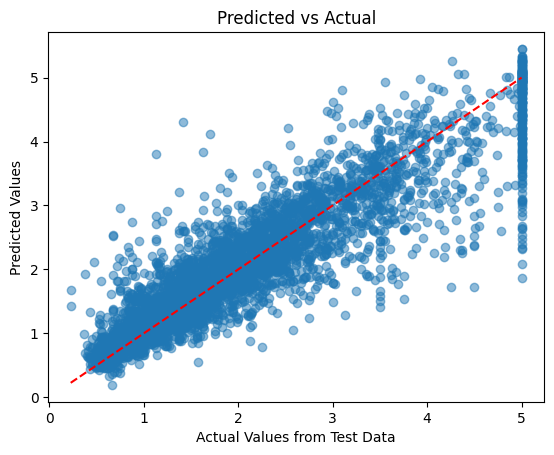

In [7]:
plt.scatter(y_test, y_pred_baseline, alpha =0.5)
plt.xlabel("Actual Values from Test Data")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()

## Iteration using GridSearch
We can expand on the above model further by finding the most optimal paramaters for this model. To do this we use GridSearch to iterate the listed outcomes.

In [8]:
from sklearn.model_selection import GridSearchCV

# Define a dictionary of parameters to test
param_grid = {
    'hidden_layer_sizes': [(64, 32), (100, 50), (32, 16)],
    'alpha': [0.0001, 0.001, 0.01], # L2 regularization penalty to prevent overfitting
    'learning_rate_init': [0.001, 0.01]
}

# Initialize a base model
base_mlp = MLPRegressor(activation='relu', solver='adam', random_state=143, max_iter=500) #This part is the same always

# Run the grid search 
grid_search = GridSearchCV(
    base_mlp, 
    param_grid, 
    cv=3, # 3-fold cross-validation splits data into 3 then averages, ex.(1,2 -> 3 , 1,3 -> 2 then 2,3 -> 1)
    scoring='neg_mean_squared_error', # target value
    n_jobs=-1, # Speeds up the process
    verbose = 1 # gives updates
)

print("Starting grid search...")
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters found: {grid_search.best_params_}")

best_baseline_model = grid_search.best_estimator_
y_pred_best_baseline = best_baseline_model.predict(X_test_scaled)
best_baseline_mse = mean_squared_error(y_test, y_pred_best_baseline)

print(f"Optimized Baseline Test Mean Squared Error: {best_baseline_mse:.4f}")

Starting grid search...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


Best parameters found: {'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001}
Optimized Baseline Test Mean Squared Error: 0.2616


# Constructing Neighbourhood Features


## Feature 1: Average Neighbour House Price (avg_nb_price)


In [9]:
from sklearn.neighbors import NearestNeighbors
import numpy as np


# 1) Extracting geographical coordinates:
# We used the original unscaled Latitude and Longitude values because neighbour relationships must be based on real spatial distance
coords_train = X_train[["Latitude", "Longitude"]].values
coords_test  = X_test[["Latitude", "Longitude"]].values

k = 10 # Number of neighbours to consider (hyperparameter)


# 2) Fitting k-Nearest Neighbours model using train locations only:
nn = NearestNeighbors(n_neighbors=k, metric="euclidean") # This model identifies geographically closest housing areas
nn.fit(coords_train)

# Finding neighbours for each trian sample:
dist_train, idx_train = nn.kneighbors(coords_train) # idx_train contains indices of neighbouring training points

# Finding neighbours for each test sample. Note that neighbours are searched only among train data. This avoids data leakage from test labels
dist_test, idx_test = nn.kneighbors(coords_test)


# 3) Computing neighbourhood statistics:
# Converting training target values to numpy array for indexing:
y_train_arr = y_train.values

# Computing average house price of neighbours for train samples:
avg_nb_price_train = np.array([
    y_train_arr[idx].mean() for idx in idx_train
])


# 4) Computing average neighbour price for test samples while still using train neighbour prices only:
avg_nb_price_test = np.array([
    y_train_arr[idx].mean() for idx in idx_test
])


# 5) Adding neighbourhood feature to dataset:
X_train["avg_nb_price"] = avg_nb_price_train # This creates a new input feature for the neural network
X_test["avg_nb_price"]  = avg_nb_price_test
print("Neighbourhood feature added successfully")


# 6) Checking dataset dimensions:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape) # Number of rows should stay the same and number of columns should increase by +1


# 7) Displaying feature names to confirm new feature added
print(X_train.columns)

Neighbourhood feature added successfully
X_train shape: (16512, 9)
X_test shape: (4128, 9)
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'avg_nb_price'],
      dtype='object')


In Part 4, we construct neighbourhood relationships using a k-nearest neighbours approach based on the geographical coordinates (latitude and longitude) of each housing area. We compute the average house price of neighbouring housing areas using the training dataset only and add this value as an additional input feature, referred to as the average neighbouring house price. This feature helps capture spatial dependency in housing prices while preventing data leakage, since information from the test labels is not used during feature construction.

## Feature 2: Average Neighbour Median Income (avg_nb_income)

On top of our avg_nb_price feature, I've added avg_nb_income which is the average income of neighbouring areas. 
Price of house tells us what people paid and their income tells us what people earn, so together they give the model two different but related angles on the same neighbourhood. 
Both of these features have high correlation with the data too.

In [10]:
# Feature 2: avg_nb_income — average median income of the same 10 nearest neighbours
# Using the neighbour indices (idx_train, idx_test) already computed by Komail's KNN above

medinc_train_arr = X_train['MedInc'].values

avg_nb_income_train = np.array([medinc_train_arr[idx].mean() for idx in idx_train])
avg_nb_income_test  = np.array([medinc_train_arr[idx].mean() for idx in idx_test])

print("done making avg neighbour income feature")

print("train data:")
print("min:", round(avg_nb_income_train.min(), 2), 
      "max:", round(avg_nb_income_train.max(), 2), 
      "mean:", round(avg_nb_income_train.mean(), 2))

print("test data:")
print("min:", round(avg_nb_income_test.min(), 2), 
      "max:", round(avg_nb_income_test.max(), 2), 
      "mean:", round(avg_nb_income_test.mean(), 2))

done making avg neighbour income feature
train data:
min: 1.21 max: 14.27 mean: 3.78
test data:
min: 1.21 max: 13.27 mean: 3.82


In [11]:
# Add both neighbourhood features to the scaled dataset and scale them
# avg_nb_price comes from Komail's feature construction above
# avg_nb_income comes from our feature construction above

X_train_final = X_train_scaled.copy()
X_test_final  = X_test_scaled.copy()

# add features
X_train_final['avg_nb_price']  = avg_nb_price_train
X_test_final['avg_nb_price']   = avg_nb_price_test

X_train_final['avg_nb_income'] = avg_nb_income_train
X_test_final['avg_nb_income']  = avg_nb_income_test

# scale the new columns
nb_scaler = StandardScaler()

X_train_final[['avg_nb_price', 'avg_nb_income']] = nb_scaler.fit_transform(
    X_train_final[['avg_nb_price', 'avg_nb_income']]
)

X_test_final[['avg_nb_price', 'avg_nb_income']] = nb_scaler.transform(
    X_test_final[['avg_nb_price', 'avg_nb_income']]
)

print("final shapes:")
print("train:", X_train_final.shape)
print("test:", X_test_final.shape)

print("features:", list(X_train_final.columns))

final shapes:
train: (16512, 10)
test: (4128, 10)
features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'avg_nb_price', 'avg_nb_income']


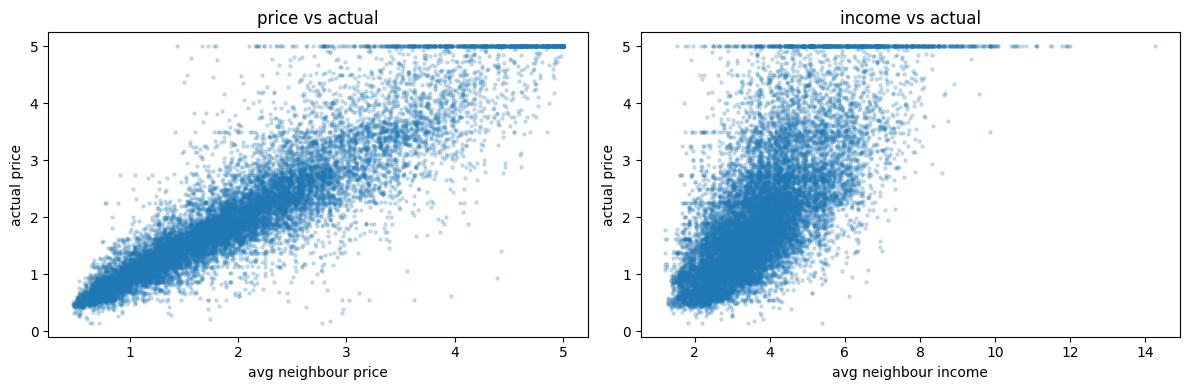

corr price vs actual: 0.9107
corr income vs actual: 0.7169


In [12]:
#Visualising both features vs actual price to see relationships

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# avg neighbour price vs actual
axes[0].scatter(avg_nb_price_train, y_train, alpha=0.2, s=5)
axes[0].set_xlabel('avg neighbour price')
axes[0].set_ylabel('actual price')
axes[0].set_title('price vs actual')

# avg neighbour income vs actual
axes[1].scatter(avg_nb_income_train, y_train, alpha=0.2, s=5)
axes[1].set_xlabel('avg neighbour income')
axes[1].set_ylabel('actual price')
axes[1].set_title('income vs actual')

plt.tight_layout()
plt.show()

# correlations
corr_price  = pd.Series(avg_nb_price_train).corr(y_train.reset_index(drop=True))
corr_income = pd.Series(avg_nb_income_train).corr(y_train.reset_index(drop=True))

print("corr price vs actual:", round(corr_price, 4))
print("corr income vs actual:", round(corr_income, 4))

Both features correlate well with the actual house price (0.91 and 0.72) which confirms they're
both useful. The difference in correlation values shows they're not just measuring
the same thing and that income adds something extra on top of price.

# Model 2
Training a second model including neighbourhood features.

In [13]:
# Model 2 — Enhanced Neural Network with neighbourhood features
# Same architecture as our baseline (64,32), ReLU, Adam, 500 iterations
# The only difference is the input: 10 features instead of 8

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

model2 = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=143
)

print('Training Model 2 (with neighbourhood features)...')
model2.fit(X_train_final, y_train)

y_pred_model2 = model2.predict(X_test_final)
model2_mse = mean_squared_error(y_test, y_pred_model2)

# Using the initial (un-tuned) baseline MSE from Part 3 for a fair comparison
# Both models use the same default architecture (64,32) so the only difference is the input features
# Note: GridSearchCV was tested on both models but made both slightly worse on the test set
# (baseline: 0.2569 -> 0.2616, model 2: 0.1681 -> 0.1711) due to overfitting on 3-fold CV splits
# So we compare the initial versions for a cleaner, fairer result

print(f'Baseline Test MSE (8 features):  {baseline_mse:.4f}')
print(f'Model 2 Test MSE  (10 features): {model2_mse:.4f}')

improvement = ((baseline_mse - model2_mse) / baseline_mse) * 100
print(f'Improvement: {improvement:.2f}%')

Training Model 2 (with neighbourhood features)...
Baseline Test MSE (8 features):  0.2569
Model 2 Test MSE  (10 features): 0.1681
Improvement: 34.57%


## Visualisations for task 4

The following plots help support the analysis of the additional neighbourhood features and model 2 results. 

### Geographic house price map

This figure shows housing locations coloured by actual price, avg_nb_price, and avg_nb_income. Similar patterns across all three maps indicate that the neighbourhood features successfully capture the underlying spatial structure.

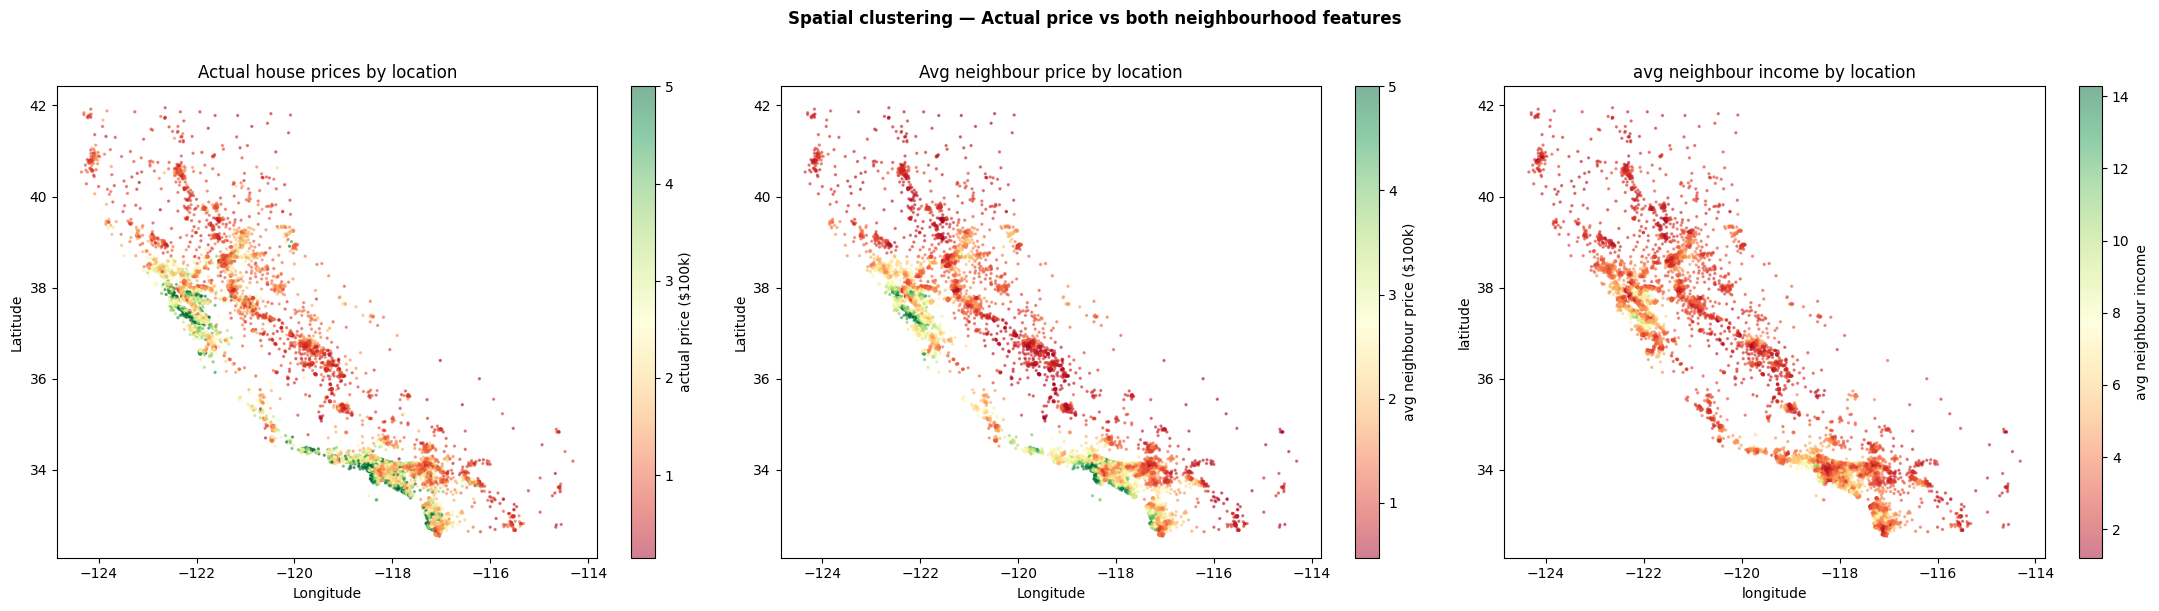

In [14]:
# plotting all training houses by lat/lon, coloured by price
# comparing actual price vs both neighbourhood features side by side
# If all three maps look similar, it confirms both features capture real spatial patterns

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

#Left map — actual house prices across california
sc1 = axes[0].scatter(
    X_train['Longitude'], X_train['Latitude'],
    c=y_train, cmap='RdYlGn', s=2, alpha=0.5
)
plt.colorbar(sc1, ax=axes[0], label='actual price ($100k)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Actual house prices by location')

# middle map — avg_nb_price feature
sc2 = axes[1].scatter(
    X_train['Longitude'], X_train['Latitude'],
    c=avg_nb_price_train, cmap='RdYlGn', s=2, alpha=0.5
)
plt.colorbar(sc2, ax=axes[1], label='avg neighbour price ($100k)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Avg neighbour price by location')

# right map — avg_nb_income feature
sc3 = axes[2].scatter(
    X_train['Longitude'], X_train['Latitude'],
    c=avg_nb_income_train, cmap='RdYlGn', s=2, alpha=0.5
)
plt.colorbar(sc3, ax=axes[2], label='avg neighbour income')
axes[2].set_xlabel('longitude')
axes[2].set_ylabel('latitude')
axes[2].set_title('avg neighbour income by location')

plt.suptitle('Spatial clustering — Actual price vs both neighbourhood features',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### Observations from the above
All three maps show the same pattern.
Expensive areas cluster along the coast, especially near the Bay Area and Los Angeles, while cheaper areas are inland. 
The avg_nb_price and avg_nb_income maps closely match the actual price map, which supports using neighbourhood features. 
It shows that location relative to nearby properties is strongly predictive of price, which is exactly what the graph based approach captures.
Avg_nb_income has a slightly smoother gradient than avg_nb_price, reflecting its lower correlation with price, around 0.72 versus 0.91. 
Still, it follows the same overall pattern, so it adds useful information rather than noise.

### Feature correlation heatmap

This heatmap shows how all 10 features correlate with each other and with the target price.
This plot shows why we specifically included our two neighbourhood features. If they had very similar correlations to each other it might suggest they're measuring the same thing. 
The last row/column shows correlations with house price.

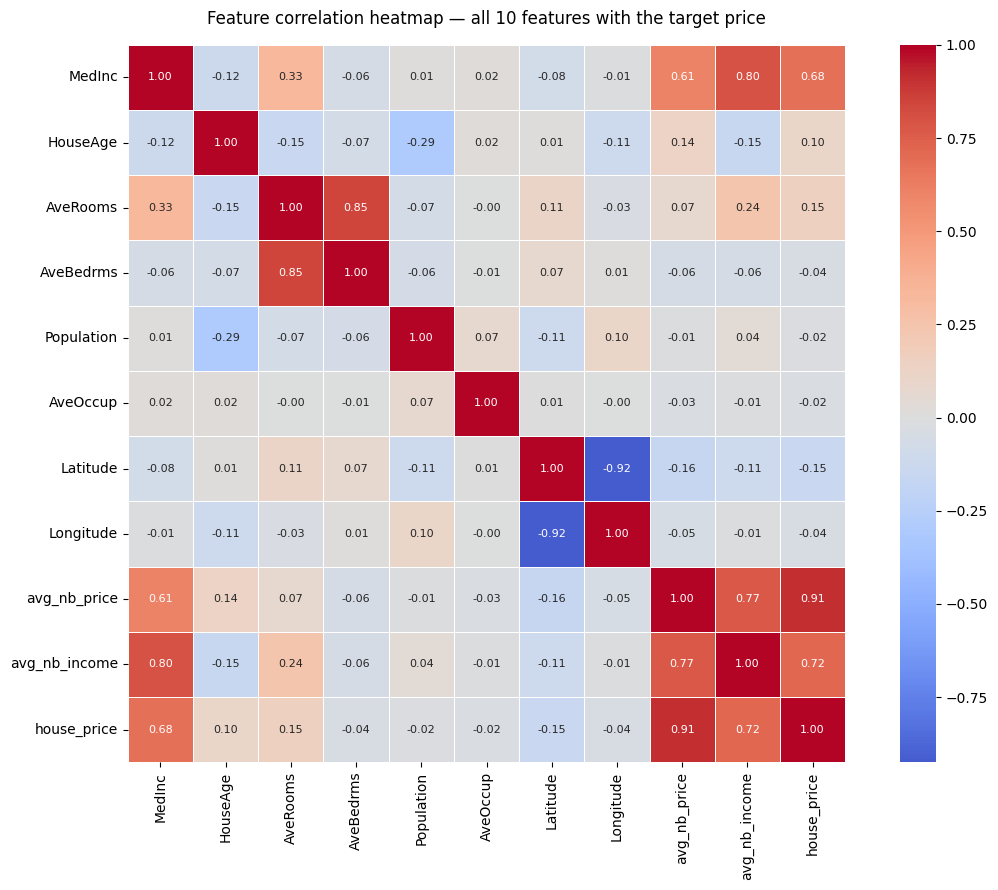

Correlations with house price (sorted):
avg_nb_price     0.911
avg_nb_income    0.717
MedInc           0.683
AveRooms         0.154
HouseAge         0.102
Population      -0.017
AveOccup        -0.023
AveBedrms       -0.039
Longitude       -0.043
Latitude        -0.147
Name: house_price, dtype: float64


In [15]:
# feature correlation heatmap code
# checking how all 10 features relate to each other and to the target price

import seaborn as sns

#Build a combined dataframe with all features and the target
corr_df = X_train_final.copy()
corr_df['house_price'] = y_train.values

#Calculate correlations
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,       # show the numbers in each cell
    fmt='.2f',        # round to 2 decimal places
    cmap='coolwarm',  # blue means negative correlation, red means positive
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('Feature correlation heatmap — all 10 features with the target price', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

# also print just each of the correlations with house price, sorted highest to lowest to show that the new features have the strongest correlations with price, even stronger than the original features which were all below 0.7 in correlation
print('Correlations with house price (sorted):')
print(corr_matrix['house_price'].drop('house_price').sort_values(ascending=False).round(3))

#### Observations from above 
The bottom row shows correlations with house price. avg_nb_price has the highest correlation of any feature at 0.91, which is even higher than median income at 0.68, the strongest of the original eight features. This makes it the most informative input in the entire feature set.

avg_nb_income has a correlation of 0.72, which is also strong. The two neighbourhood features correlate with each other at 0.77, so they are clearly related but not identical. This means they are not redundant. avg_nb_price reflects what nearby houses sell for, while avg_nb_income reflects what people in the area earn. They capture different aspects of the same neighbourhood, so including both is justified.

In comparison, latitude and longitude only correlate at negative 0.15 and negative 0.04 with price, which shows that raw coordinates alone are much weaker than the neighbourhood statistics derived from them.

## Visualisations for task 5

### Mean squared error comparison - Improvement from baseline to model 2

This is the main results chart, it directly compares the test MSE of the baseline model (8 features, no neighbourhood info) against model 2 (10 features, with neighbourhood info).


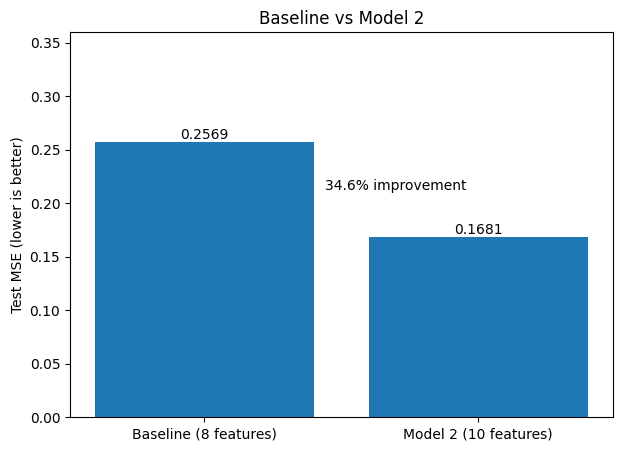

baseline mse: 0.2569
model 2 mse: 0.1681
improvement: 34.57 %


In [16]:
# MSE bar chart: baseline vs model 2

models = ['Baseline (8 features)', 'Model 2 (10 features)']
mses = [baseline_mse, model2_mse]

plt.figure(figsize=(7, 5))

# basic bar chart
plt.bar(models, mses)

# add mse values on top
for i in range(len(mses)):
    plt.text(i, mses[i] + 0.003, round(mses[i], 4), ha='center')

# calculate improvement
improvement = ((baseline_mse - model2_mse) / baseline_mse) * 100

# small text to show the percentage improvement between the bars
mid_x = 0.7
mid_y = (baseline_mse + model2_mse) / 2

plt.text(mid_x, mid_y, str(round(improvement, 1)) + '% improvement',
         ha='center')

# labels and title
plt.ylabel('Test MSE (lower is better)')
plt.title('Baseline vs Model 2')

plt.ylim(0, baseline_mse * 1.4)

plt.show()

# print results
print('baseline mse:', round(baseline_mse, 4))
print('model 2 mse:', round(model2_mse, 4))
print('improvement:', round(improvement, 2), '%')


#### Interpretation of the above

Model 2 achieves a test MSE of 0.1681 compared to the baseline value of 0.2569, which is a 34.6% reduction in error. 
This improvement comes from adding just two neighbourhood features (avg_nb_price and avg_nb_income) while keeping the same model architecture (64, 32 hidden layers, ReLU, Adam).

We did not use GridSearchCV for the final comparison because it actually made both models slightly worse on the test set (overfitting on the 3-fold CV splits). 
Using the untuned versions gives a fairer comparison since both models share the exact same architecture, the only variable is the input features.

### Actual vs Predicted — Baseline vs Model 2

Side-by-side scatter plots comparing how well each model predicts house prices. 
The closer points fall to the red dashed line (perfect prediction), the better the model. 
Model 2 should show a tighter cluster around the line thanks to the neighbourhood features.

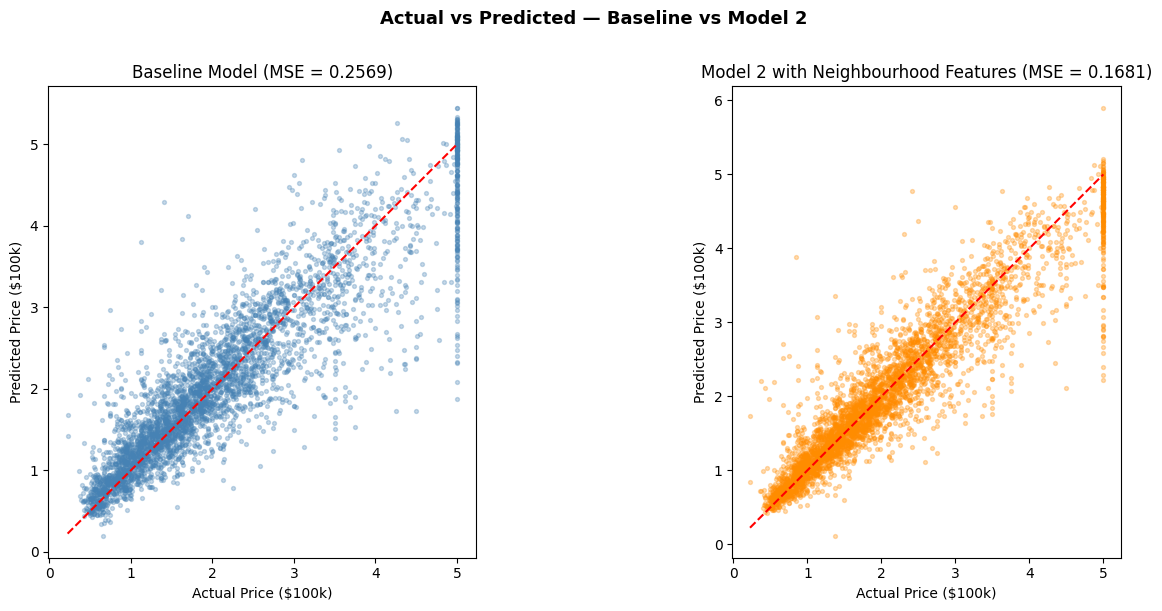

Baseline MSE: 0.2569
Model 2 MSE:  0.1681
Improvement:  34.6%


In [17]:
# Side-by-side actual vs predicted scatter plots
# Left: Our baseline model (8 features)
# Right: Model 2 with neighbourhood features (10 features)
# Using y_pred_baseline from Part 3 and y_pred_model2 from above

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — Baseline
axes[0].scatter(y_test, y_pred_baseline, alpha=0.3, s=8, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Price ($100k)')
axes[0].set_ylabel('Predicted Price ($100k)')
axes[0].set_title(f'Baseline Model (MSE = {baseline_mse:.4f})')
axes[0].set_aspect('equal', adjustable='box')

# Right — Model 2
axes[1].scatter(y_test, y_pred_model2, alpha=0.3, s=8, color='darkorange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[1].set_xlabel('Actual Price ($100k)')
axes[1].set_ylabel('Predicted Price ($100k)')
axes[1].set_title(f'Model 2 with Neighbourhood Features (MSE = {model2_mse:.4f})')
axes[1].set_aspect('equal', adjustable='box')

plt.suptitle('Actual vs Predicted — Baseline vs Model 2', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Baseline MSE: {baseline_mse:.4f}')
print(f'Model 2 MSE:  {model2_mse:.4f}')
print(f'Improvement:  {improvement:.1f}%')

#### Interpretation

Model 2's predictions cluster much more tightly around the perfect prediction line compared to the baseline. 
The baseline shows wider scatter, especially for mid-to-high value properties, while Model 2 reduces this spread significantly. 
The vertical clustering at the top of both plots is due to a cap on reported house values in the dataset, which neither model can overcome. 
Overall, adding the two neighbourhood features produces visibly more accurate predictions across the full price range.